In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

In [ ]:
# Annual prediction model performance
linear = pd.read_csv("/common/home/lh811/Documents/ML_Pricing/data/linear_models.csv")
tree = pd.read_csv("/common/home/lh811/Documents/ML_Pricing/data/tree_models.csv")
nn = pd.read_csv("/common/home/lh811/Documents/ML_Pricing/data/nn_models.csv")

In [4]:
nn = nn.rename(columns={'test_mse':'mse_test',
                'test_r2':'r2_test',
                'architecture':'method'})

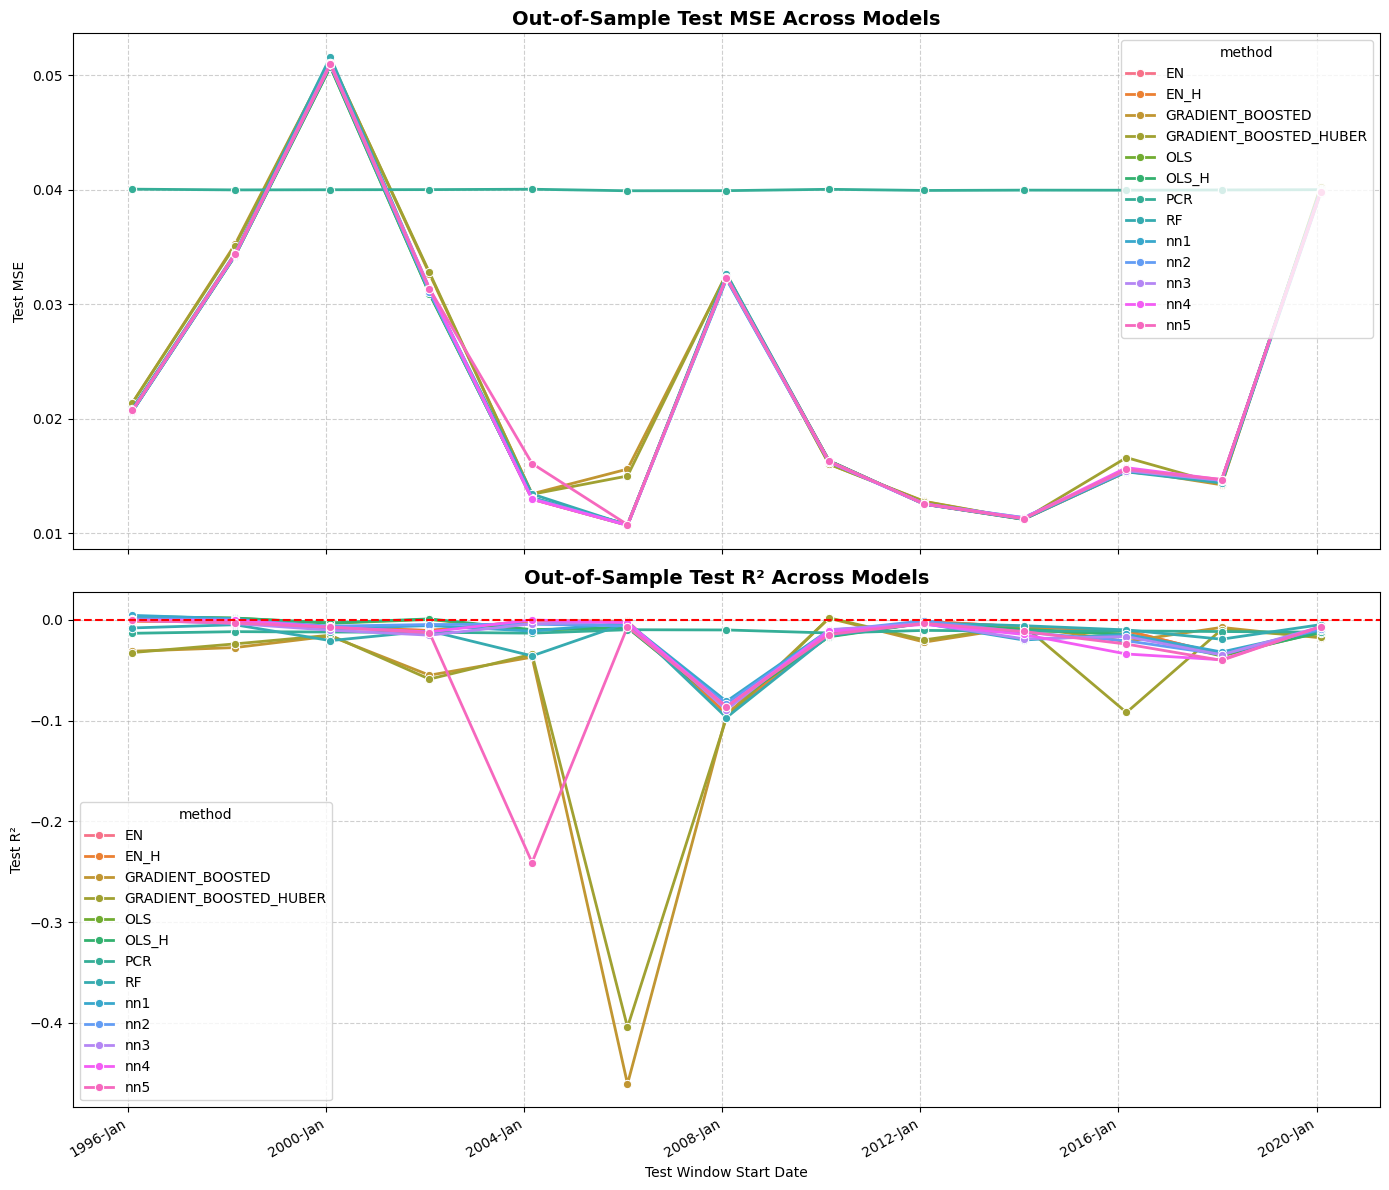

In [6]:
# -----------------------------
# NN
# -----------------------------
nn_plot = nn[
    nn['mse_test'].notna()][
        [
            'test_start',
            'mse_test',
            'r2_test',
            'method'
        ]
    ].copy()

# -----------------------------
# Regular tree models
# -----------------------------

tree_regular = tree[
    tree['mse_test'].notna()
][
    [
        'test_start',
        'mse_test',
        'r2_test',
        'method'
    ]
].copy()

# -----------------------------
# Huber boosted trees
# -----------------------------

tree_huber = tree[
    tree['mse_test_huber'].notna()
].copy()

# Build clean dataframe explicitly
tree_huber = pd.DataFrame({
    'test_start': tree_huber['test_start'],
    'mse_test': tree_huber['mse_test_huber'],
    'r2_test': tree_huber['r2_test_huber'],
    'method': tree_huber['method']
})

# =====================================================
# PREP LINEAR MODELS
# =====================================================

linear_models = linear[
    [
        'test_start',
        'mse_test',
        'r2_test',
        'method'
    ]
].copy()

# =====================================================
# COMBINE
# =====================================================

all_models = pd.concat(
    [
        linear_models,
        tree_regular,
        tree_huber,
        nn_plot
    ],
    ignore_index=True
)

# Convert dates
all_models['test_start'] = pd.to_datetime(
    all_models['test_start']
)

# Sort values
all_models = all_models.sort_values(
    by=['method', 'test_start']
)

# =====================================================
# PLOTS
# =====================================================

fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(14, 12),
    sharex=True
)

# ---------------------------------------------------
# TEST MSE
# ---------------------------------------------------

sns.lineplot(
    data=all_models,
    x='test_start',
    y='mse_test',
    hue='method',
    marker='o',
    linewidth=2,
    ax=axes[0]
)

axes[0].set_title(
    'Out-of-Sample Test MSE Across Models',
    fontsize=14,
    fontweight='bold'
)

axes[0].set_ylabel('Test MSE')

axes[0].grid(
    True,
    linestyle='--',
    alpha=0.6
)

# ---------------------------------------------------
# TEST R²
# ---------------------------------------------------

sns.lineplot(
    data=all_models,
    x='test_start',
    y='r2_test',
    hue='method',
    marker='o',
    linewidth=2,
    ax=axes[1]
)

axes[1].set_title(
    'Out-of-Sample Test R² Across Models',
    fontsize=14,
    fontweight='bold'
)

axes[1].set_xlabel('Test Window Start Date')

axes[1].set_ylabel('Test R²')

axes[1].grid(
    True,
    linestyle='--',
    alpha=0.6
)

axes[1].axhline(
    y=0,
    color='red',
    linestyle='--',
    linewidth=1.5
)

# ---------------------------------------------------
# FORMAT DATES
# ---------------------------------------------------

axes[1].xaxis.set_major_formatter(
    mdates.DateFormatter('%Y-%b')
)

fig.autofmt_xdate()

plt.tight_layout()

plt.show()

RF and GB (MSE) overfit like a mug (expected)